tpm2026_figures.py
==================
Run as a Jupyter notebook (paste each section into a cell) or as a script.
Generates all figures for the TPM 2026 paper main body:
  - otica_baseline_recovery.pdf   (Fig 1)
  - general_hybrid_test.pdf       (Fig 2  — 4-method, 2×1)
  - eeg_artifact_removal.pdf      (Fig 3)
Outputs are written to ../uai_workshop/.

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd
import scipy.stats
from sklearn.decomposition import FastICA
from sklearn.exceptions import ConvergenceWarning
from joblib import Parallel, delayed
from tqdm.notebook import tqdm          # use tqdm.tqdm if running as script
import warnings, gc, os

import mne                              # for EEG application
from picard import picard               # pip install python-picard

from wasserstein_ica import WassersteinICA

In [3]:
COLUMN_IN = 3.5          # approximate UAI proceedings column width (inches)
SCALE     = 2            # generate at 2× → fonts appear correct when LaTeX
                         # includes at \columnwidth

SAVE_DIR = '../uai_workshop/'
os.makedirs(SAVE_DIR, exist_ok=True)

# Colorblind-safe palette — reserved per method throughout the paper
PALETTE = {
    'OT-ICA':  '#D55E00',   # vermilion
    'FastICA': '#0173B2',   # blue
    'JADE':    '#029E73',   # teal
    'InfoMax': '#CC78BC',   # purple
}
METHOD_ORDER = ['OT-ICA', 'FastICA', 'JADE', 'InfoMax']


def set_tpm_theme():
    """Calibrated for COLUMN_IN × SCALE figures (fonts ≈ 9 pt at print size)."""
    plt.rcParams.update({
        'figure.dpi':            300,
        'font.size':             9  * SCALE,
        'axes.titlesize':        10 * SCALE,
        'axes.labelsize':        9  * SCALE,
        'xtick.labelsize':       8  * SCALE,
        'ytick.labelsize':       8  * SCALE,
        'legend.fontsize':       8  * SCALE,
        'legend.title_fontsize': 8  * SCALE,
        'lines.linewidth':       1.5,
        'lines.markersize':      5,
        'axes.grid':             True,
        'grid.alpha':            0.3,
        'grid.linestyle':        '--',
        'axes.spines.top':       False,
        'axes.spines.right':     False,
        'axes.axisbelow':        True,
    })

set_tpm_theme()

In [4]:
def amari_error(W, A):
    """
    W : estimated unmixing (d×d)
    A : true mixing (d×d)
    Returns scalar ∈ [0, 1]; 0 = perfect separation.
    """
    if W is None or np.any(np.isnan(W)):
        return np.nan
    P = np.abs(W @ A)
    n = P.shape[0]
    row_max = np.max(P, axis=1, keepdims=True)
    col_max = np.max(P, axis=0, keepdims=True)
    return (np.sum(P / row_max - 1.0) + np.sum(P / col_max - 1.0)) / (2.0 * n)

In [5]:
# =============================================================================
# JADE (pure NumPy, no extra dependency)
# =============================================================================
def jade_ica(X):
    """
    JADE — Joint Approximate Diagonalization of Eigenmatrices.
    Reference: Cardoso & Souloumiac, IEE Proc. F 1993 / Cardoso 1999.

    X   : (d, n) raw data matrix (not pre-whitened).
    Returns W : (d, d) total unmixing matrix such that  W @ X  ≈ sources.
    """
    d, n = X.shape

    # --- 1. Whiten ---------------------------------------------------------
    C = X @ X.T / n
    evals, evecs = np.linalg.eigh(C)
    evals = np.maximum(evals, 1e-10)
    W_white = (1.0 / np.sqrt(evals))[:, None] * evecs.T   # (d, d)
    Xw = W_white @ X                                        # whitened data

    # --- 2. Build d(d+1)/2 fourth-order cumulant matrices ------------------
    # Q_{ij}[k,l] = E[x_i x_j x_k x_l]
    #             - delta_{ij} delta_{kl}
    #             - delta_{ik} delta_{jl}
    #             - delta_{il} delta_{jk}
    # (for unit-covariance whitened data)
    Qset = []
    for i in range(d):
        for j in range(i, d):
            xij = Xw[i] * Xw[j]                          # (n,)
            Q   = (xij[None, :] * Xw) @ Xw.T / n        # E[xi xj x x^T]
            if i == j:
                Q -= np.eye(d)    # -delta_{ij} I
                Q[i, i] -= 2.0   # -e_i e_j^T - e_j e_i^T (both → [i,i])
            else:
                Q[i, j] -= 1.0   # -delta_{ik}delta_{jl}
                Q[j, i] -= 1.0   # -delta_{il}delta_{jk}
            Qset.append((Q + Q.T) / 2.0)

    # --- 3. Joint diagonalisation via Jacobi sweeps ------------------------
    # Accumulated rotation V:  independent components = V @ Xw
    V = np.eye(d)

    for _sweep in range(200):
        changed = False
        for p in range(d - 1):
            for q in range(p + 1, d):
                g = np.array([Q[p, p] - Q[q, q] for Q in Qset])
                h = np.array([2.0 * Q[p, q]     for Q in Qset])
                ton  = float(np.dot(g, g) - np.dot(h, h))
                toff = float(2.0 * np.dot(g, h))

                denom = ton + np.sqrt(ton**2 + toff**2 + 1e-30)
                if abs(toff) < 1e-12 * (abs(denom) + 1e-12):
                    continue

                theta = 0.5 * np.arctan2(toff, denom)
                c, s  = np.cos(theta), np.sin(theta)
                if abs(s) < 1e-12:
                    continue

                changed = True

                # Apply Givens rotation to every cumulant matrix in-place
                for iq in range(len(Qset)):
                    Q  = Qset[iq]
                    pr = c * Q[p, :] - s * Q[q, :]
                    qr = s * Q[p, :] + c * Q[q, :]
                    Q[p, :] = pr;  Q[q, :] = qr
                    pc = c * Q[:, p] - s * Q[:, q]
                    qc = s * Q[:, p] + c * Q[:, q]
                    Q[:, p] = pc;  Q[:, q] = qc

                # Accumulate into V
                Vp = c * V[p, :] - s * V[q, :]
                Vq = s * V[p, :] + c * V[q, :]
                V[p, :] = Vp;  V[q, :] = Vq

        if not changed:
            break

    return V @ W_white   # (d, d) total unmixing applied to raw X


In [6]:
# =============================================================================
# InfoMax wrapper (via Picard)
# =============================================================================
def infomax_ica(X, n_restarts=5, seed_offset=0):
    """
    Extended InfoMax via Picard (fun='tanh', extended=True → handles
    both sub- and super-Gaussian sources).
    Returns W_total : (d, d).
    """
    best_W, best_err = None, np.inf
    for seed in range(seed_offset, seed_offset + n_restarts):
        try:
            K, W, _ = picard(
                X, fun='tanh', ortho=False, extended=True,
                max_iter=1000, tol=1e-8, random_state=seed, whiten=True
            )
            W_total = W @ K
            return W_total          # picard converges quickly; first run usually fine
        except Exception:
            continue
    return best_W   # fallback (None if all restarts failed)

In [7]:
# =============================================================================
# Full Hybrid data generator
# =============================================================================
def generate_full_hybrid(d, n, seed=None):
    """
    d sources: 1 standard Gaussian + (d-1) draws from the hybrid pool.
    Pool: {Laplace, Bernoulli±1, Uniform, Student-t(3), Poisson(3),
           Binomial(10,0.5), Chi²(2), Exponential(1)}.
    Returns (X, A): mixed data (d×n) and true mixing matrix (d×d).
    """
    rng = np.random.default_rng(seed)

    def _lap():  return rng.laplace(0, 1/np.sqrt(2), n)
    def _ber():  return rng.choice([-1., 1.], n).astype(float)
    def _uni():  return rng.uniform(-np.sqrt(3), np.sqrt(3), n)
    def _stu():  s = rng.standard_t(3, n); return s / (s.std() + 1e-9)
    def _poi():  s = rng.poisson(3, n).astype(float); return (s - s.mean()) / (s.std() + 1e-9)
    def _bin():  s = rng.binomial(10, .5, n).astype(float); return (s - s.mean()) / (s.std() + 1e-9)
    def _chi():  s = rng.chisquare(2, n); return (s - s.mean()) / (s.std() + 1e-9)
    def _exp():  s = rng.exponential(1, n); return (s - s.mean()) / (s.std() + 1e-9)

    pool = [_lap, _ber, _uni, _stu, _poi, _bin, _chi, _exp]

    sources = [rng.standard_normal(n)]
    for _ in range(d - 1):
        sources.append(pool[rng.integers(len(pool))]())

    S = np.stack(sources)
    rng.shuffle(S)          # hide which row is Gaussian

    A = rng.standard_normal((d, d))
    while np.linalg.cond(A) > 100:
        A = rng.standard_normal((d, d))

    return A @ S, A

In [8]:
# =============================================================================
# 4-method trial worker
# =============================================================================
def run_trial(dim, trial, n_samples, method):
    """Single ICA trial. Returns {'Dim', 'Method', 'Error', 'Conv'}."""
    torch.set_num_threads(1)
    X_np, A = generate_full_hybrid(dim, n_samples, seed=trial * 131 + dim * 7)

    score, converged = np.nan, False

    try:
        # ---- FastICA -------------------------------------------------------
        if method == 'FastICA':
            best = np.inf
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', ConvergenceWarning)
                for r in range(50):
                    try:
                        fica = FastICA(n_components=dim, max_iter=10000,
                                       tol=1e-4, random_state=trial * 1000 + r)
                        fica.fit(X_np.T)
                        err = amari_error(fica.components_, A)
                        if not np.isnan(err) and err < best:
                            best = err
                    except Exception:
                        pass
            score = best if not np.isinf(best) else np.nan

        # ---- JADE ----------------------------------------------------------
        elif method == 'JADE':
            W = jade_ica(X_np)
            if W is not None:
                score = amari_error(W, A)

        # ---- InfoMax -------------------------------------------------------
        elif method == 'InfoMax':
            W = infomax_ica(X_np, n_restarts=5, seed_offset=trial * 17)
            if W is not None:
                score = amari_error(W, A)

        # ---- OT-ICA --------------------------------------------------------
        elif method == 'OT-ICA':
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            X_t = torch.tensor(X_np, dtype=torch.float32, device=device)
            ica = WassersteinICA(X_t)
            ica.whiten()
            W_white_np = ica.W_white.cpu().numpy()

            n_restarts = min(dim * 4, 150)
            extracted = []
            for _ in range(dim):
                prev = torch.stack(extracted) if extracted else None
                w, _ = ica.optimize_wasserstein2(
                    prev_components=prev, max_iter=200,
                    n_restarts=n_restarts, dither_sigma=0.01)
                extracted.append(w)

            W_sym = ica.optimize_symmetric(
                n_components=dim, max_iter=400, lr=0.25,
                init_w=torch.stack(extracted),
                optimizer='stiefel', dither_sigma=0.01, batch_size=1024)
            score = amari_error(W_sym.cpu().numpy() @ W_white_np, A)

            del X_t, ica
            gc.collect()

        if not np.isnan(score) and score < 0.5:
            converged = True

    except Exception:
        pass

    return {'Dim': dim, 'Method': method, 'Error': score, 'Conv': int(converged)}

In [9]:
# =============================================================================
# Run hybrid experiment
# =============================================================================
DIMS      = [10, 20, 30]
N_TRIALS  = 10
N_SAMPLES = 10_000

tasks = [
    (d, t, N_SAMPLES, m)
    for d  in DIMS
    for t  in range(N_TRIALS)
    for m  in METHOD_ORDER
]

print(f'Running {len(tasks)} trials across {len(DIMS)} dims × {len(METHOD_ORDER)} methods × {N_TRIALS} trials …')
results = Parallel(n_jobs=8)(
    delayed(run_trial)(*task) for task in tqdm(tasks)
)

df = pd.DataFrame(results)
df['Error']   = df['Error'].clip(upper=1.5).fillna(1.5)
df['Success'] = ((df['Error'] < 0.3) & df['Conv'].astype(bool)).astype(float) * 100

# Quick sanity-check table
print('\nMean Amari Error per method × dimension:')
print(df.groupby(['Dim', 'Method'])['Error'].mean().unstack().round(3))

Running 120 trials across 3 dims × 4 methods × 10 trials …


  0%|          | 0/120 [00:00<?, ?it/s]

/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Mean Amari Error per method × dimension:
Method  FastICA  InfoMax    JADE  OT-ICA
Dim                                     
10       -8.685   -8.660  -5.715  -8.956
20      -18.614  -18.551 -12.519 -18.887
30      -28.357  -28.198 -19.565 -28.660


/tmp/ipykernel_951823/87053499.py:17: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 3.0}` instead.

  sns.barplot(
/tmp/ipykernel_951823/87053499.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


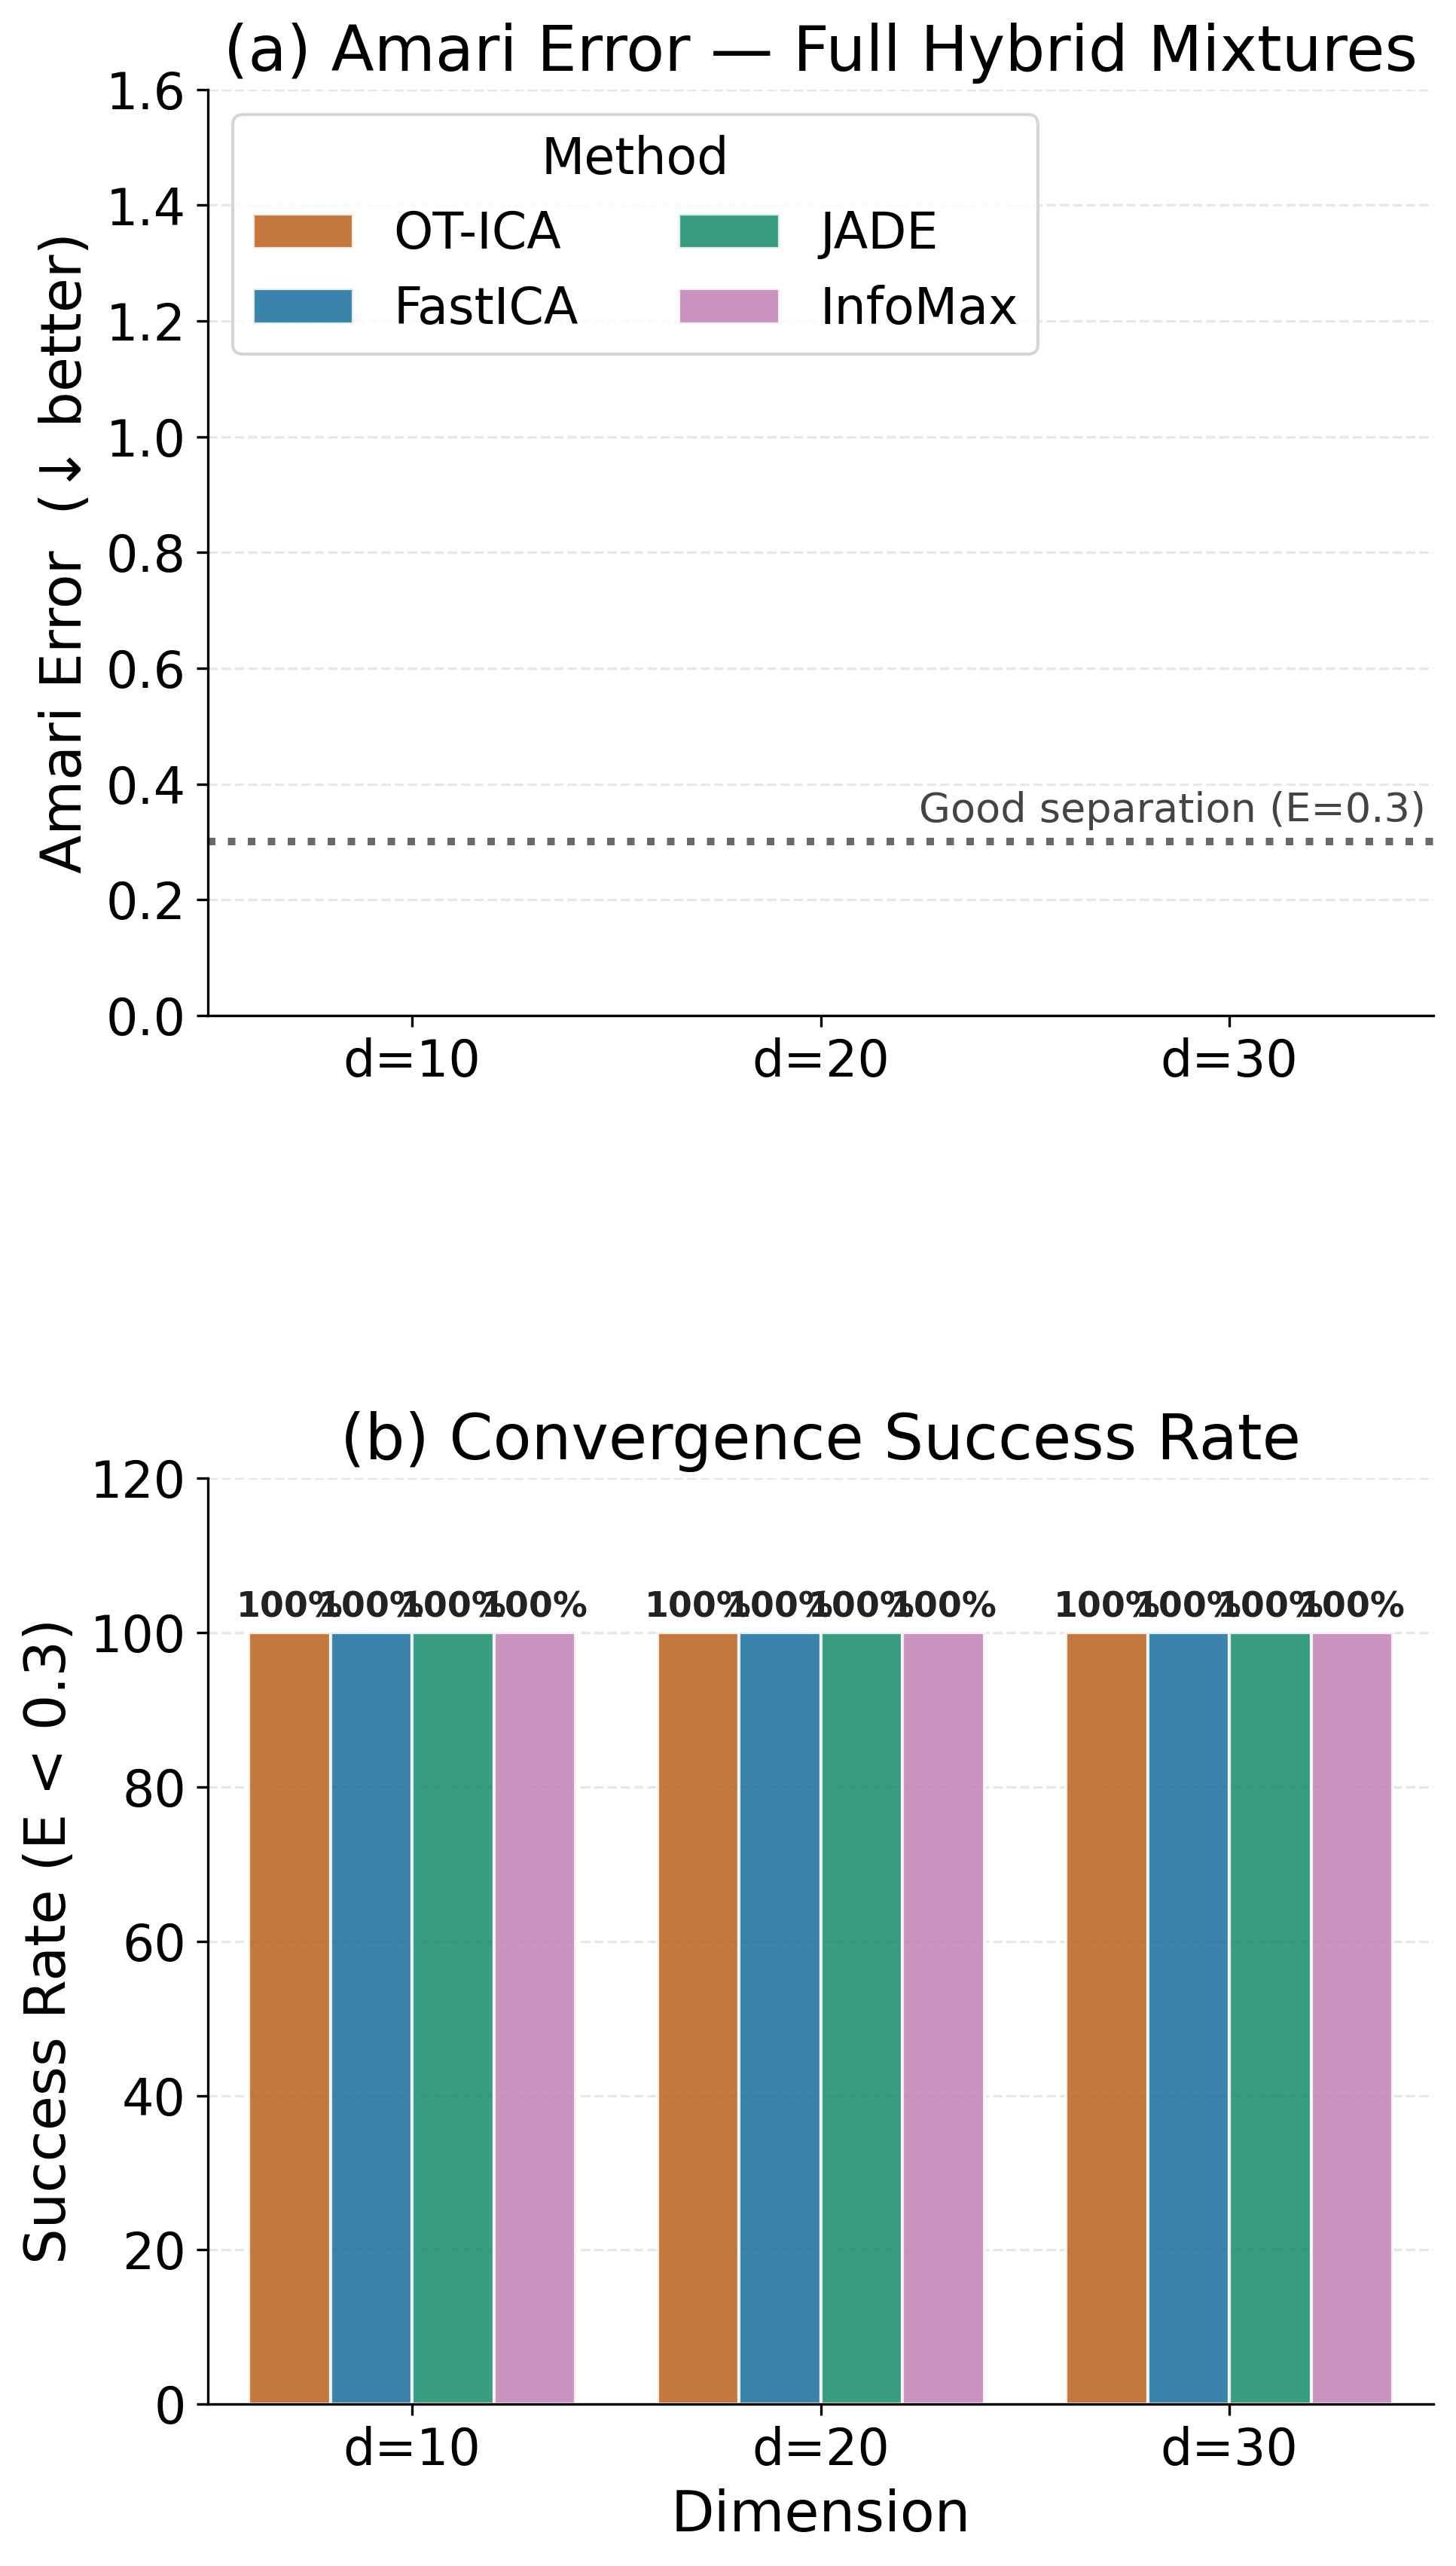

Saved ../uai_workshop/general_hybrid_test.pdf


In [10]:
# =============================================================================
# Figure 2: 2×1 hybrid comparison  (general_hybrid_test.pdf)
# =============================================================================
set_tpm_theme()

dim_label = {10: 'd=10', 20: 'd=20', 30: 'd=30'}
df['Dim_label'] = df['Dim'].map(dim_label)
DIM_ORDER_LABELS = ['d=10', 'd=20', 'd=30']

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(COLUMN_IN * SCALE, COLUMN_IN * SCALE * 1.9),
    gridspec_kw={'hspace': 0.50}
)

# ── Row 1: Amari Error ──────────────────────────────────────────────────────
sns.barplot(
    data=df, x='Dim_label', y='Error', hue='Method',
    hue_order=METHOD_ORDER, order=DIM_ORDER_LABELS,
    palette=PALETTE, ax=ax1,
    errorbar='ci', capsize=0.04, errwidth=1.5 * SCALE,
    alpha=0.85, edgecolor='white'
)
ax1.axhline(0.3, color='#444', ls=':', lw=1.2 * SCALE, alpha=0.8)
ax1.text(2.48, 0.32, 'Good separation (E=0.3)',
         ha='right', va='bottom', fontsize=6.5 * SCALE, color='#444')
ax1.set_ylim(0, 1.6)
ax1.set_xlabel('')
ax1.set_ylabel('Amari Error  (↓ better)')
ax1.set_title('(a) Amari Error — Full Hybrid Mixtures')
ax1.legend(title='Method', loc='upper left', ncol=2, frameon=True)

# ── Row 2: Success Rate ──────────────────────────────────────────────────────
sns.barplot(
    data=df, x='Dim_label', y='Success', hue='Method',
    hue_order=METHOD_ORDER, order=DIM_ORDER_LABELS,
    palette=PALETTE, ax=ax2,
    errorbar=None, alpha=0.85, edgecolor='white'
)

# Annotate bars with percentage
n_methods = len(METHOD_ORDER)
n_dims    = len(DIM_ORDER_LABELS)
for bar_idx, patch in enumerate(ax2.patches[:n_methods * n_dims]):
    h = patch.get_height()
    if not np.isnan(h) and h >= 0:
        ax2.text(
            patch.get_x() + patch.get_width() / 2., h + 1.0,
            f'{h:.0f}%',
            ha='center', va='bottom',
            fontsize=5.5 * SCALE, color='#222', fontweight='bold'
        )

ax2.set_ylim(0, 120)
ax2.set_xlabel('Dimension')
ax2.set_ylabel('Success Rate (E < 0.3)')
ax2.set_title('(b) Convergence Success Rate')
if ax2.get_legend() is not None:
    ax2.get_legend().remove()

fig.tight_layout()
out = SAVE_DIR + 'general_hybrid_test.pdf'
fig.savefig(out, format='pdf', bbox_inches='tight')
plt.show()
print(f'Saved {out}')

Baseline Amari Error: -2.9849


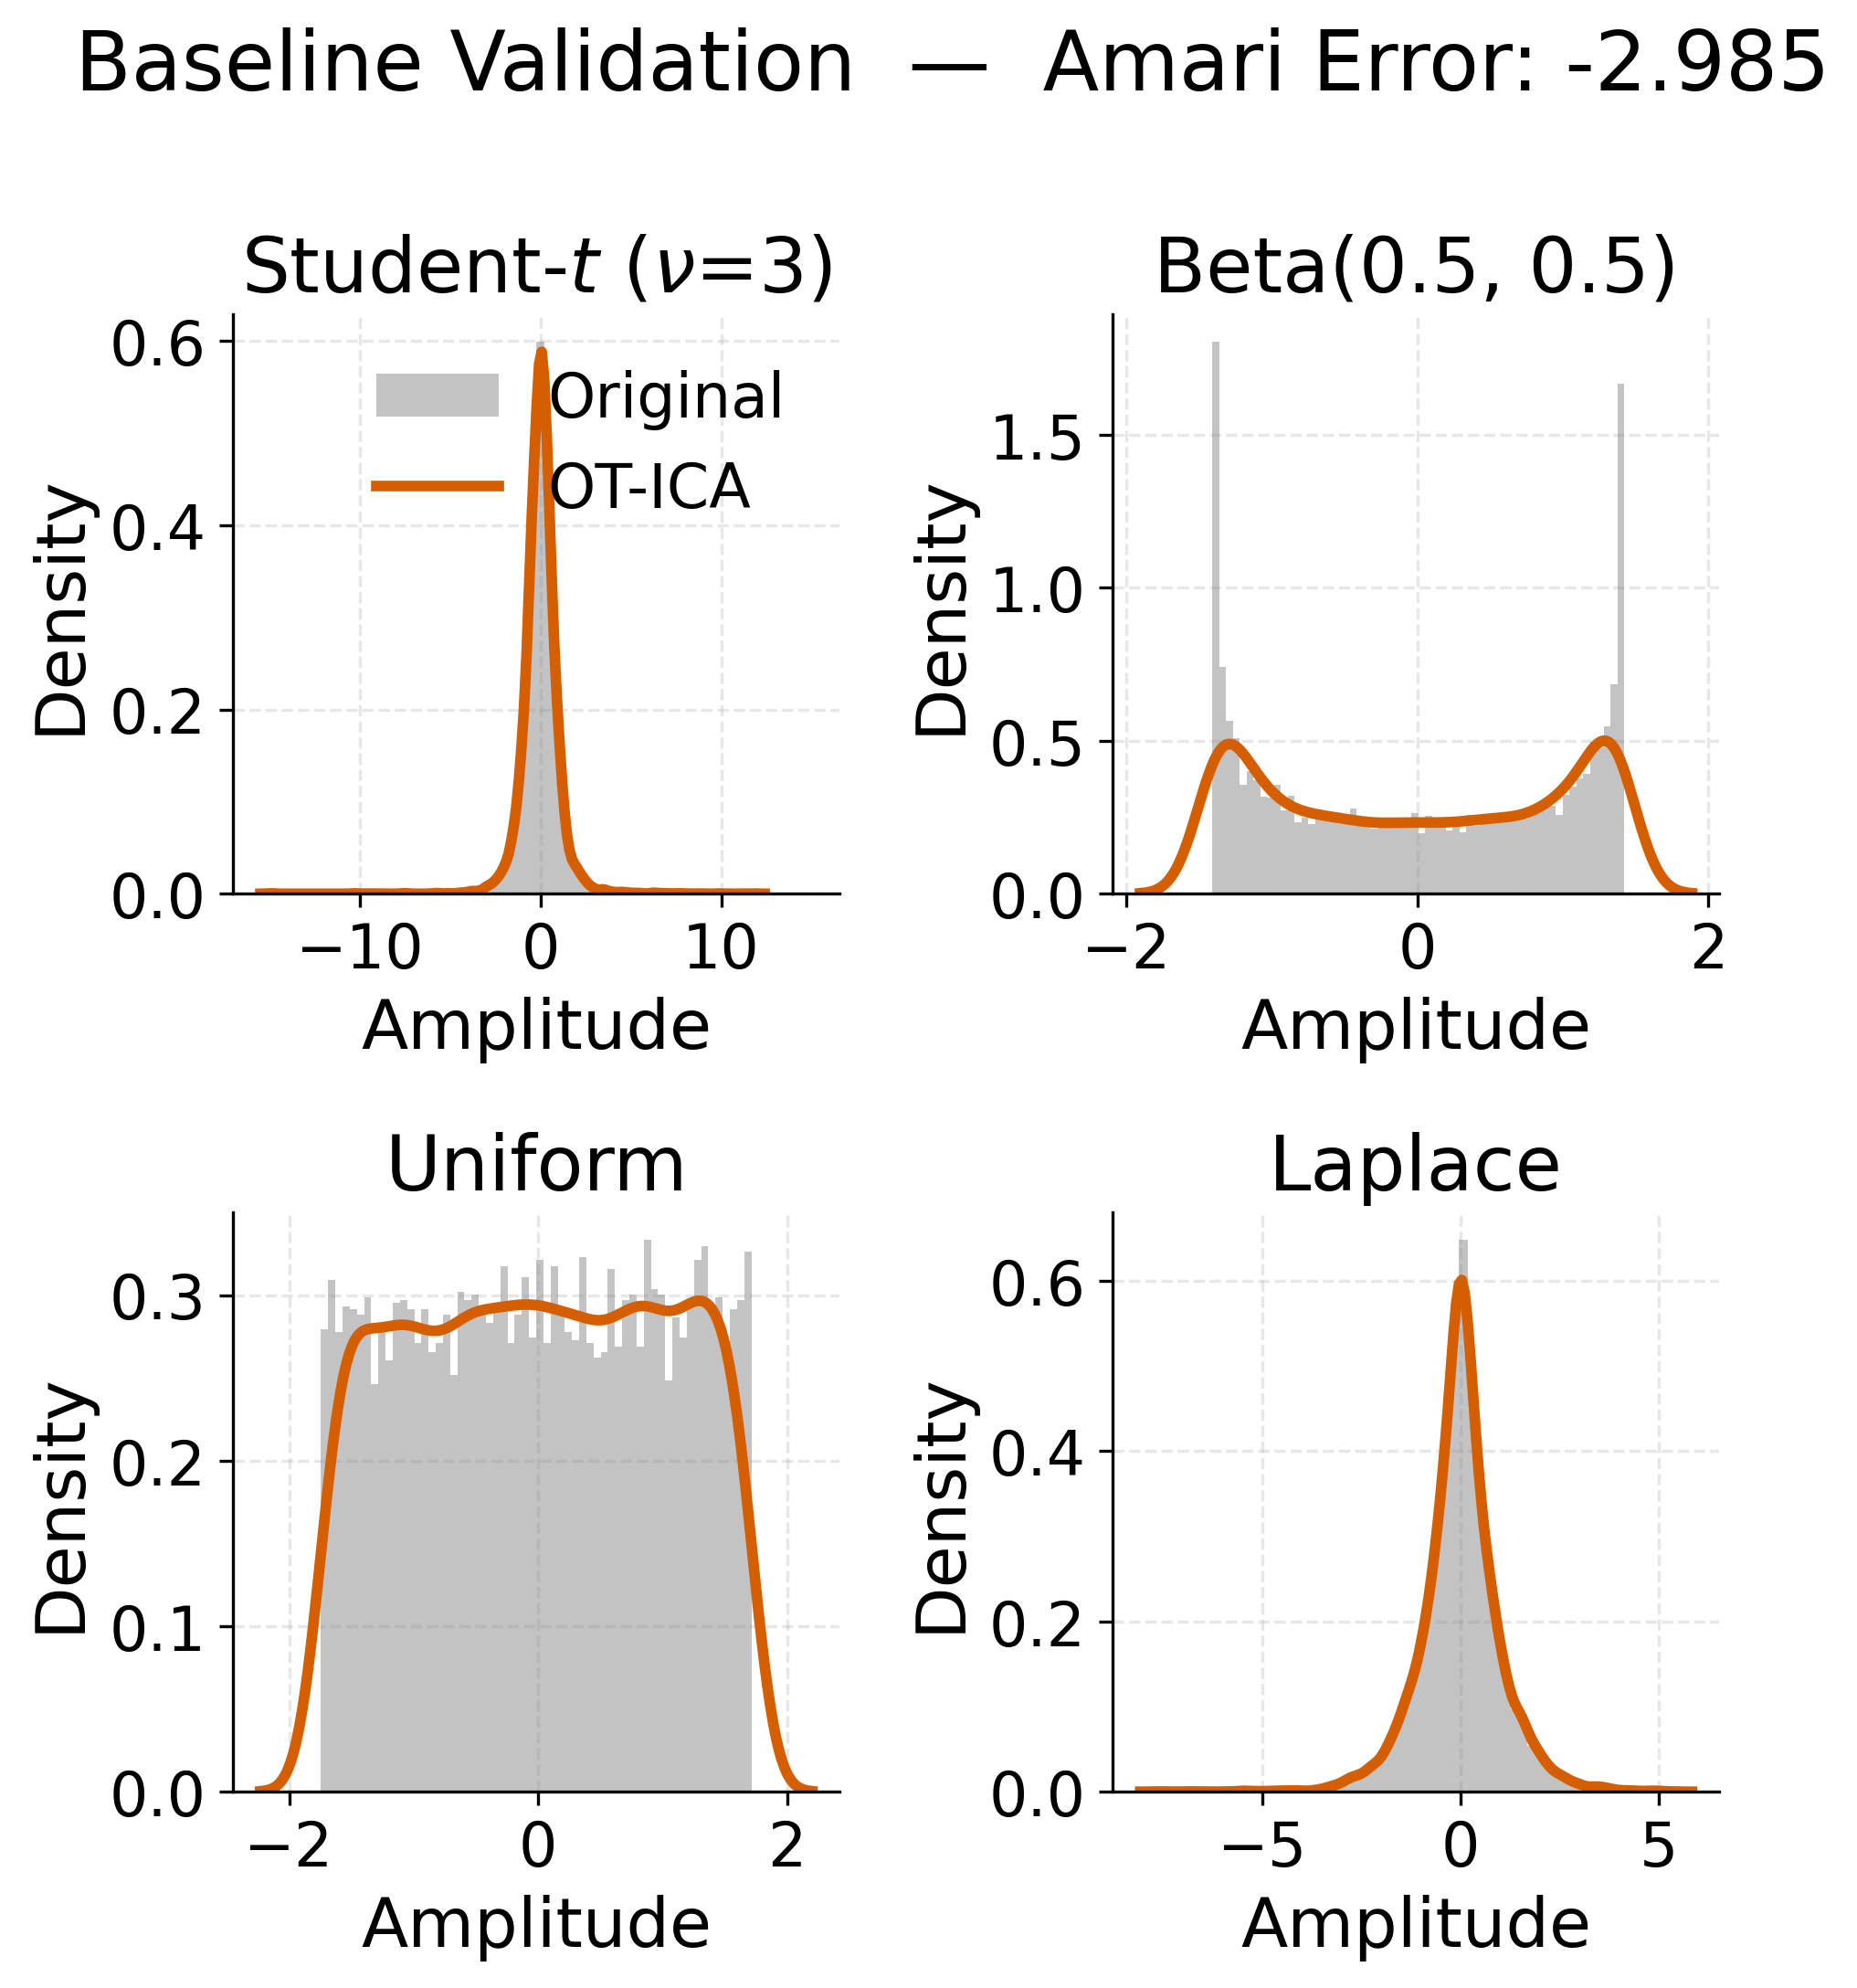

Saved ../uai_workshop/otica_baseline_recovery.pdf


In [11]:
# =============================================================================
# Figure 1: Baseline recovery  (otica_baseline_recovery.pdf)
# =============================================================================
np.random.seed(42); torch.manual_seed(42)
n_base, d_base = 10_000, 4

s1 = np.random.laplace(0, 1/np.sqrt(2), n_base)
s2 = np.random.uniform(-np.sqrt(3), np.sqrt(3), n_base)
s3 = scipy.stats.t.rvs(df=3, size=n_base); s3 = s3 / s3.std()
s4 = np.random.beta(0.5, 0.5, n_base);     s4 = (s4 - s4.mean()) / s4.std()
S_true = np.stack([s1, s2, s3, s4])
S_true = (S_true - S_true.mean(1, keepdims=True)) / S_true.std(1, keepdims=True)
src_names = ['Laplace', 'Uniform', r'Student-$t$ ($\nu$=3)', r'Beta(0.5, 0.5)']

A_base = np.random.randn(d_base, d_base)
while np.linalg.cond(A_base) > 20:
    A_base = np.random.randn(d_base, d_base)
X_base = A_base @ S_true

# Run OT-ICA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_t_base = torch.tensor(X_base, dtype=torch.float32, device=device)
ica_base  = WassersteinICA(X_t_base)
ica_base.whiten()
W_wh = ica_base.W_white.cpu().numpy()

extracted = []
for _ in range(d_base):
    prev = torch.stack(extracted) if extracted else None
    w, _ = ica_base.optimize_wasserstein2(
        prev_components=prev, max_iter=200, n_restarts=50, dither_sigma=0.01)
    extracted.append(w)

W_sym = ica_base.optimize_symmetric(
    n_components=d_base, max_iter=400, lr=0.25,
    init_w=torch.stack(extracted),
    optimizer='stiefel', dither_sigma=0.01, batch_size=1024)
W_total_base = W_sym.cpu().numpy() @ W_wh
score_base   = amari_error(W_total_base, A_base)
Y_est_base   = W_total_base @ X_base

print(f'Baseline Amari Error: {score_base:.4f}')

# Match estimated components to original sources
P_match = np.abs(W_total_base @ A_base)
matches = [
    (i, int(np.argmax(P_match[i])), float(np.sign(P_match[i, np.argmax(P_match[i])])))
    for i in range(d_base)
]

# Plot
set_tpm_theme()
fig, axes = plt.subplots(
    2, 2,
    figsize=(COLUMN_IN * SCALE, COLUMN_IN * SCALE),
    gridspec_kw={'hspace': 0.55, 'wspace': 0.45}
)
axes = axes.flatten()

for ax_idx, (est_idx, src_idx, sgn) in enumerate(matches):
    ax   = axes[ax_idx]
    orig = S_true[src_idx]
    est  = Y_est_base[est_idx] * sgn

    ax.hist(orig, bins=60, density=True, alpha=0.5,
            color='#888888', edgecolor='none', label='Original')
    sns.kdeplot(est, ax=ax, color=PALETTE['OT-ICA'],
                linewidth=1.4 * SCALE, label='OT-ICA')
    ax.set_title(src_names[src_idx])
    ax.set_xlabel('Amplitude')
    ax.set_ylabel('Density')
    if ax_idx == 0:
        ax.legend(loc='upper right', frameon=False)

fig.suptitle(f'Baseline Validation  —  Amari Error: {score_base:.3f}', y=1.03)
out = SAVE_DIR + 'otica_baseline_recovery.pdf'
fig.savefig(out, format='pdf', bbox_inches='tight')
plt.show()
print(f'Saved {out}')

Loading MNE sample dataset …
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
EEG shape: (5, 6007)  (6007 samples @ 601 Hz)


/tmp/ipykernel_951823/3944532645.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


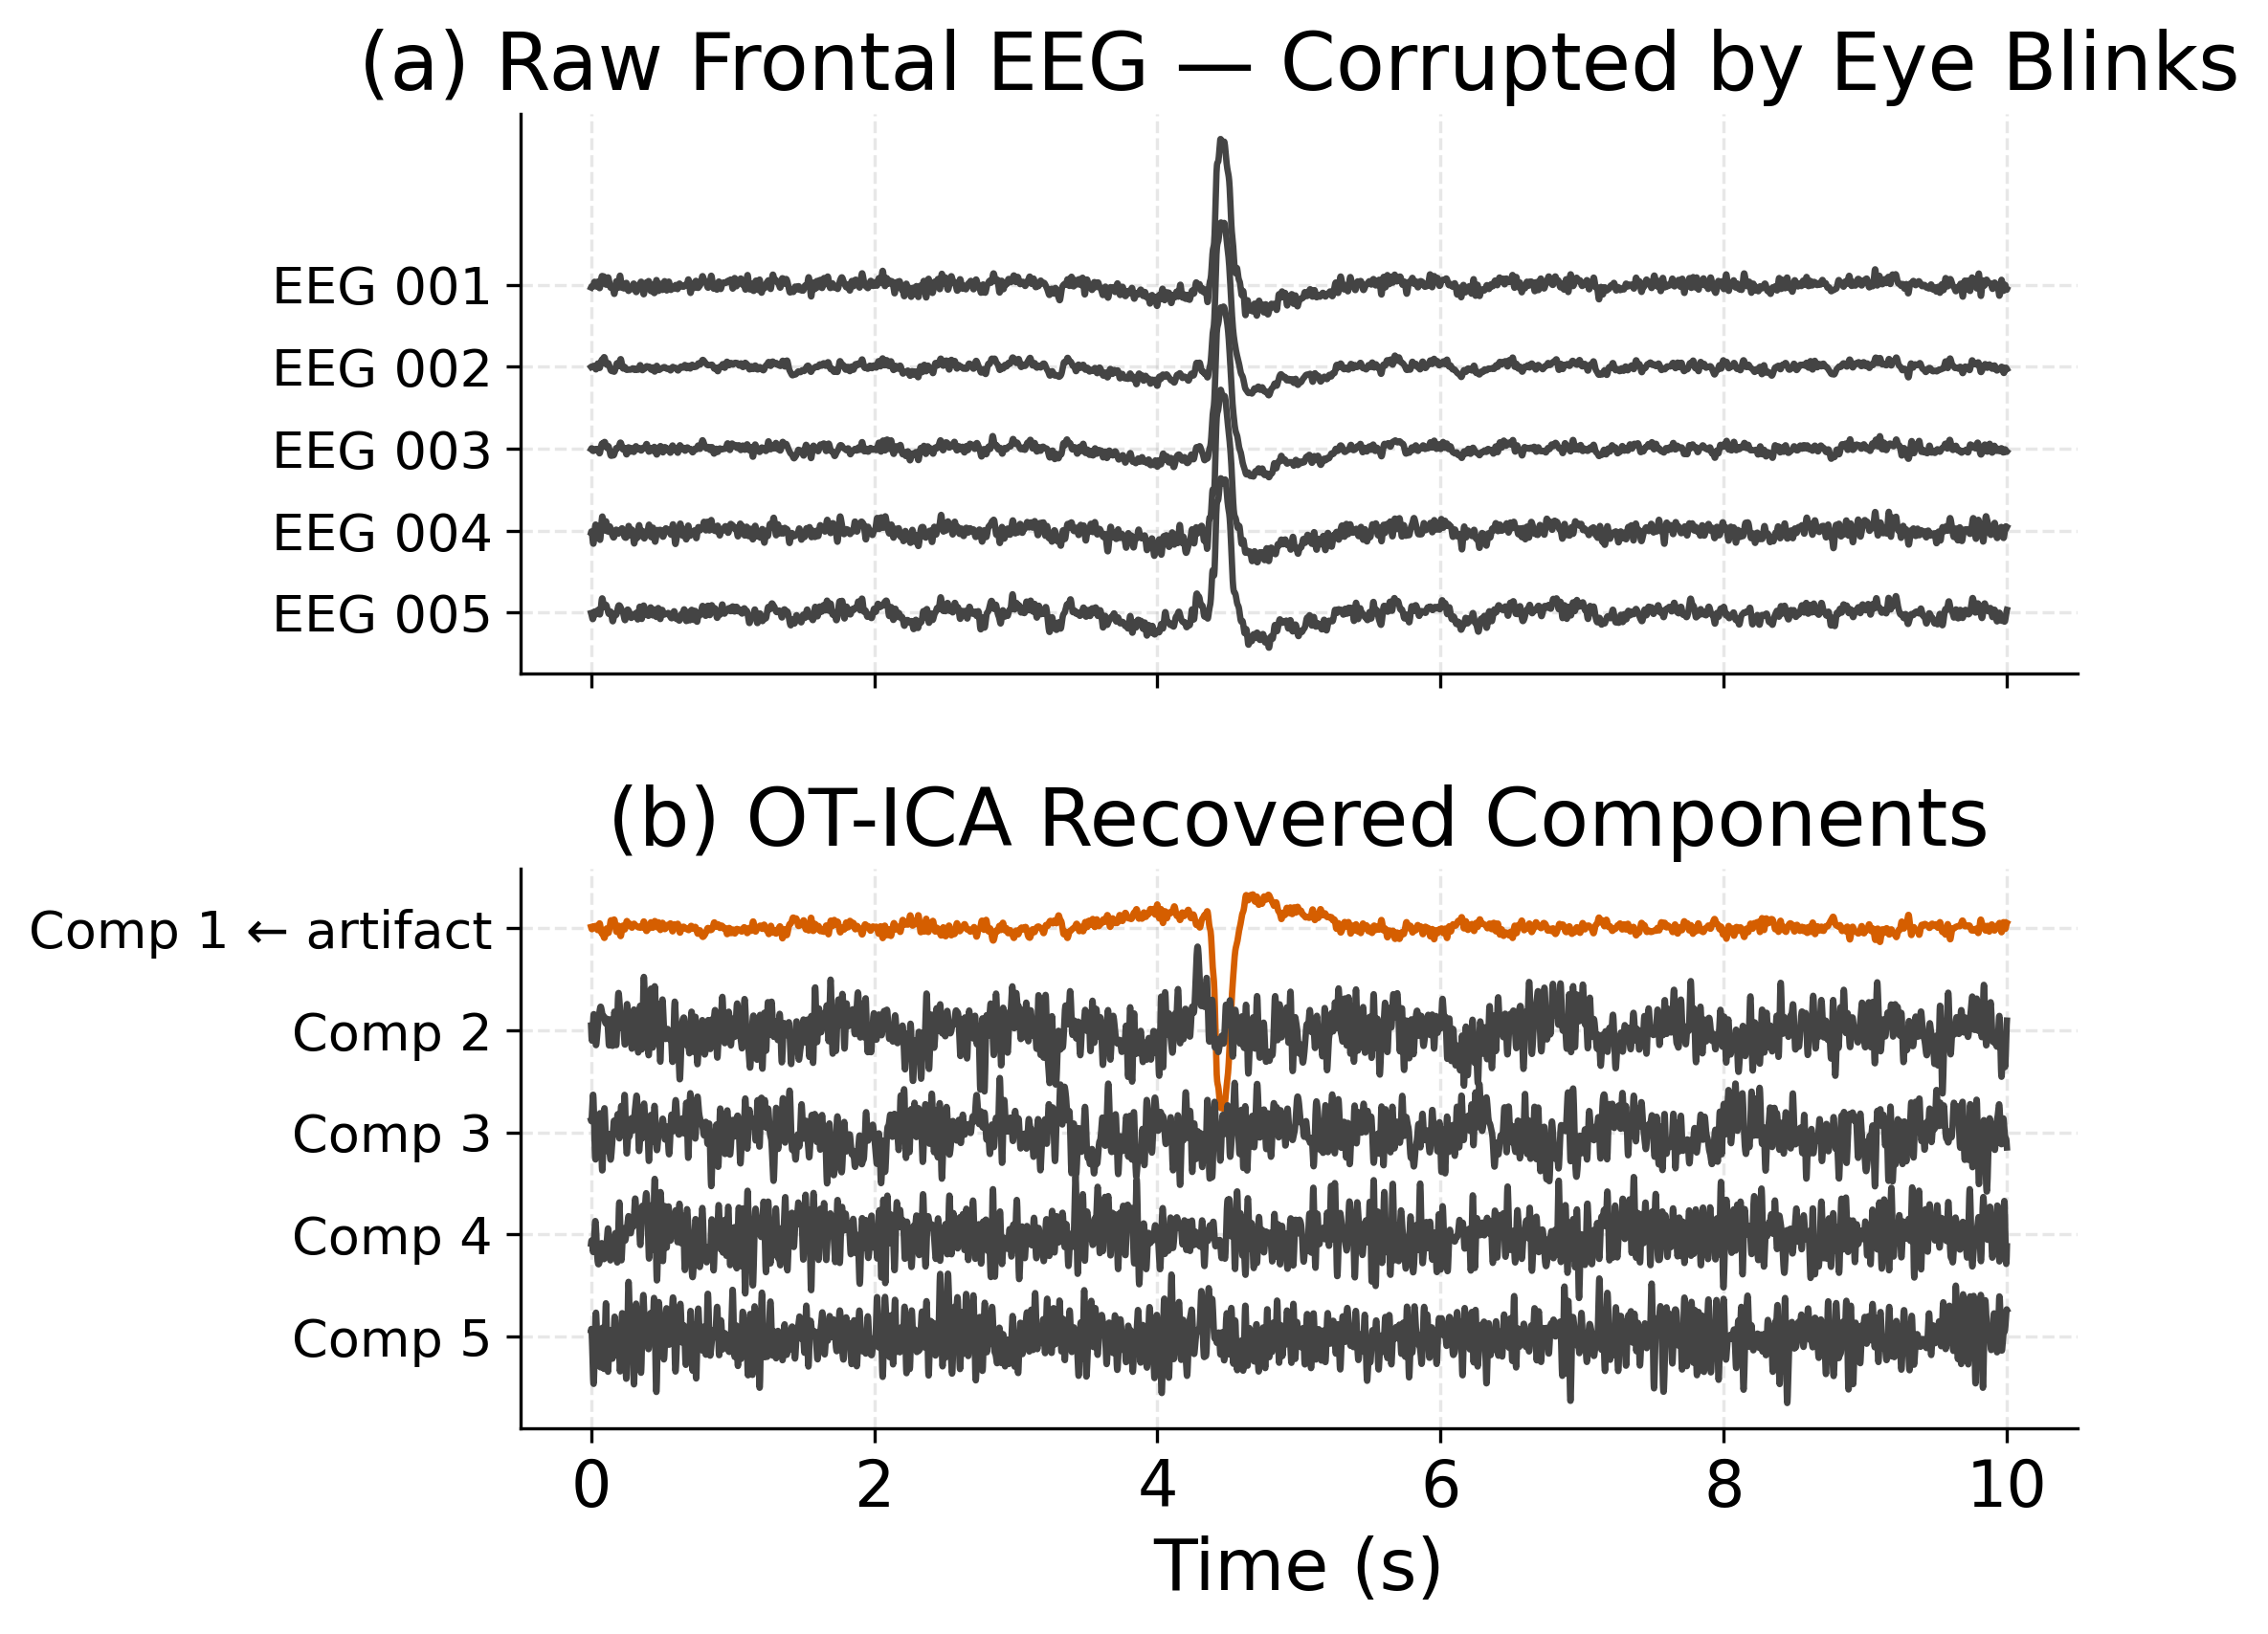

Saved ../uai_workshop/eeg_artifact_removal.pdf

All TPM 2026 figures written to ../uai_workshop/


In [14]:
# =============================================================================
# Figure 3: EEG application  (eeg_artifact_removal.pdf)
# =============================================================================

# ---- Load MNE sample data (downloads ~1.5 GB on first run) -----------------
print('Loading MNE sample dataset …')
sample_data_folder  = mne.datasets.sample.data_path()
sample_data_raw_file = (sample_data_folder / 'MEG' / 'sample'
                        / 'sample_audvis_raw.fif')

raw = mne.io.read_raw_fif(sample_data_raw_file, preload=True, verbose=False)
raw.filter(l_freq=1.0, h_freq=40.0, fir_design='firwin', verbose=False)
raw.crop(tmin=10.0, tmax=20.0)

frontal_channels = ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005']
raw.pick_channels(frontal_channels)

X_eeg  = raw.get_data()
time   = raw.times
dim_eeg = X_eeg.shape[0]

X_eeg = (X_eeg - X_eeg.mean(1, keepdims=True)) / X_eeg.std(1, keepdims=True)
print(f'EEG shape: {X_eeg.shape}  ({X_eeg.shape[1]} samples @ {raw.info["sfreq"]:.0f} Hz)')

# ---- Run OT-ICA ------------------------------------------------------------
X_t_eeg  = torch.tensor(X_eeg, dtype=torch.float32, device=device)
model_eeg = WassersteinICA(X_t_eeg)
model_eeg.whiten()

extracted_eeg = []
for _ in range(dim_eeg):
    prev = torch.stack(extracted_eeg) if extracted_eeg else None
    w, _ = model_eeg.optimize_wasserstein2(
        prev_components=prev, max_iter=200, n_restarts=50, dither_sigma=0.01)
    extracted_eeg.append(w)

W_eeg = model_eeg.optimize_symmetric(
    n_components=dim_eeg, max_iter=400, lr=0.05,
    init_w=torch.stack(extracted_eeg),
    optimizer='stiefel', batch_size=512, dither_sigma=0.01)
Z_hat = W_eeg.cpu().numpy() @ model_eeg.X_white.cpu().numpy()

# Identify artifact component: highest kurtosis (most impulsive = blinks)
kurtoses = scipy.stats.kurtosis(Z_hat, axis=1)
artifact_idx = int(np.argmax(kurtoses))
comp_colors  = ['#D55E00' if i == artifact_idx else '#444444'
                for i in range(dim_eeg)]
comp_labels  = [f'Comp {i+1} ← artifact' if i == artifact_idx
                else f'Comp {i+1}'
                for i in range(dim_eeg)]

# ---- Plot ------------------------------------------------------------------
set_tpm_theme()

OFFSET = 5.5   # vertical spacing between traces
fig, axes_eeg = plt.subplots(
    2, 1,
    figsize=(COLUMN_IN * SCALE, COLUMN_IN * SCALE * 0.85),
    sharex=True,
    gridspec_kw={'hspace': 0.35}
)

# Raw EEG
for i in range(dim_eeg):
    axes_eeg[0].plot(time, X_eeg[i] - i * OFFSET,
                     color='#444444', linewidth=0.8 * SCALE)
axes_eeg[0].set_yticks([-OFFSET * i for i in range(dim_eeg)])
axes_eeg[0].set_yticklabels(frontal_channels)
axes_eeg[0].set_title('(a) Raw Frontal EEG — Corrupted by Eye Blinks')

# OT-ICA components
for i in range(dim_eeg):
    axes_eeg[1].plot(time, Z_hat[i] - i * OFFSET,
                     color=comp_colors[i], linewidth=0.8 * SCALE)
axes_eeg[1].set_yticks([-OFFSET * i for i in range(dim_eeg)])
axes_eeg[1].set_yticklabels(comp_labels)
axes_eeg[1].set_xlabel('Time (s)')
axes_eeg[1].set_title('(b) OT-ICA Recovered Components')

# Highlight the artifact component band
y_top = 1.5
y_bot = -(artifact_idx * OFFSET) - OFFSET * 0.5
for ax in axes_eeg:
    ax.tick_params(axis='y', labelsize=6.5 * SCALE)

fig.tight_layout()
out = SAVE_DIR + 'eeg_artifact_removal.pdf'
fig.savefig(out, format='pdf', bbox_inches='tight')
plt.show()
print(f'Saved {out}')

print('\nAll TPM 2026 figures written to', SAVE_DIR)